In [70]:
import pandas as pd

# load the data

df = pd.read_csv('train.csv')

# strip whitespace from column names (just in case)
df.columns = df.columns.str.strip()

# display the columns so we can see what names are present
print("columns in dataframe:", df.columns.tolist())

# map categorical to numeric
df['Sex'] = df['Sex'].map({'male': 1, 'female': 0})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

# drop rows where Age is NaN only
rows_before = len(df)
df = df.dropna(subset=['Age', 'Embarked'])
rows_after = len(df)
print(f"Rows before dropna (Age subset): {rows_before}, after: {rows_after}")

# prepare features and target
x = df.drop(['Survived', 'PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)

y = df['Survived']

columns in dataframe: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
Rows before dropna (Age subset): 891, after: 712


In [71]:
from sklearn.model_selection import train_test_split

# Train/Test Split လုပ်ခြင်း
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [72]:
from sklearn.preprocessing import StandardScaler

# Feature Scaling (SVM အတွက် မရှိမဖြစ်လိုအပ်ပါတယ်)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [73]:
from sklearn.svm import SVC

# Linear SVM Model တည်ဆောက်ခြင်း
linear_model = SVC(kernel='linear', C=2.0) 
linear_model.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",2.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [74]:
from sklearn.metrics import accuracy_score

# ရလဒ်ထုတ်ကြည့်ခြင်း
y_pred = linear_model.predict(X_test)
print("--- Linear SVM Result ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")

--- Linear SVM Result ---
Accuracy Score: 74.83%



Feature columns and dtypes:
 Pclass        int64
Sex           int64
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked    float64
dtype: object
Sample of feature data:
    Pclass  Sex   Age  SibSp  Parch     Fare  Embarked
0       3    1  22.0      1      0   7.2500       0.0
1       1    0  38.0      1      0  71.2833       1.0
2       3    0  26.0      0      0   7.9250       0.0
3       1    0  35.0      1      0  53.1000       0.0
4       3    1  35.0      0      0   8.0500       0.0
Unique values per column (first few):
Pclass [3 1 2]
Sex [1 0]
Age [22. 38. 26. 35. 54.  2. 27. 14.  4. 58.]
SibSp [1 0 3 4 2 5]
Parch [0 1 2 5 3 4 6]
Fare [ 7.25   71.2833  7.925  53.1     8.05   51.8625 21.075  11.1333 30.0708
 16.7   ]
Embarked [0. 1. 2.]

Coefficient magnitudes:
     Feature  Importance
1       Sex    0.963237
0    Pclass    0.000151
3     SibSp    0.000120
2       Age    0.000087
5      Fare    0.000069
4     Parch    0.000065
6  Embarked    

C:\Users\pyaep\AppData\Local\Temp\ipykernel_25772\3590546472.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


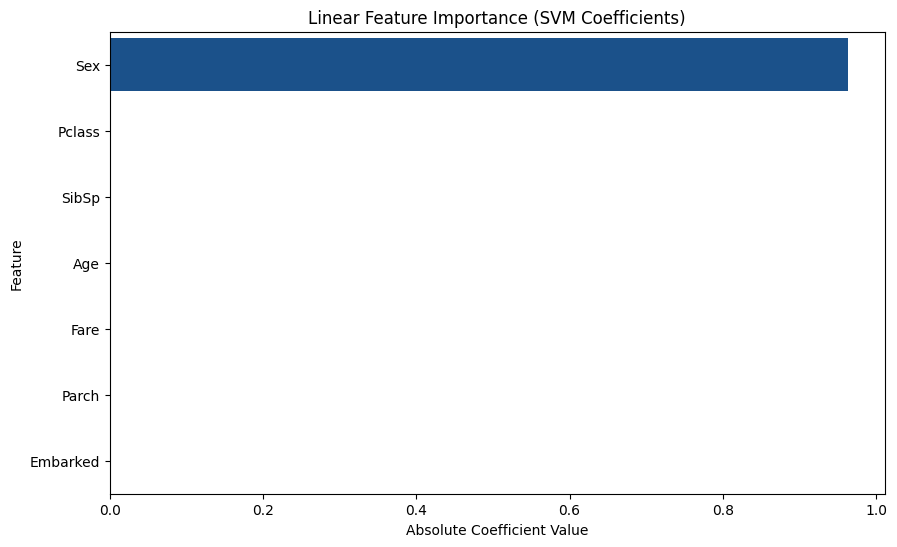

In [75]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# inspect features before plotting
print("Feature columns and dtypes:\n", x.dtypes)
print("Sample of feature data:\n", x.head())
print("Unique values per column (first few):")
for col in x.columns:
    print(col, x[col].unique()[:10])

linear_importance = np.abs(linear_model.coef_[0])
feat_importance = pd.DataFrame({'Feature': x.columns, 'Importance': linear_importance})
feat_importance = feat_importance.sort_values(by='Importance', ascending=False)

print("\nCoefficient magnitudes:\n", feat_importance)

# Visualization 
plt.figure(figsize=(10, 6))
sns.barplot(
    x='Importance', 
    y='Feature', 
    data=feat_importance, 
    # hue='Feature', 
    palette='Blues_r', 
    # legend=True
)

plt.title('Linear Feature Importance (SVM Coefficients)')
plt.xlabel('Absolute Coefficient Value')
plt.show()

In [76]:
print("--- Feature Importance Table ---")
print(feat_importance)

--- Feature Importance Table ---
    Feature  Importance
1       Sex    0.963237
0    Pclass    0.000151
3     SibSp    0.000120
2       Age    0.000087
5      Fare    0.000069
4     Parch    0.000065
6  Embarked    0.000037


In [78]:
import pandas as pd
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler

# CSV ဖိုင်ကို ဖတ်ခြင်း
df = pd.read_csv('train.csv')

# drop rows where the selected features are NaN before visualization
vis_df = df[['Sex', 'Pclass', 'Survived']].dropna()

vis_df['Sex'] = vis_df['Sex'].map({'male': 1, 'female': 0})

# Visualization အတွက် Feature ၂ ခုသာ ရွေးချယ်ခြင်းနှင့် Scaling လုပ်ခြင်း
X_vis = vis_df[['Sex', 'Pclass']].values
y_vis = vis_df['Survived'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_vis)

# Linear SVM Model ကို တည်ဆောက်ပြီး Training ပေးခြင်း
model = SVC(kernel='linear', C=2.0)
model.fit(X_scaled, y_vis)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",2.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [79]:
import numpy as np

# မျက်နှာပြင်အတွက် အစက်အပြောက်များ တည်ဆောက်ခြင်း
h = .02  # အစက်အပြောက်များ၏ အကွာအဝေး (Mesh step size)
x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Grid တစ်ခုလုံးပေါ်ရှိ အမှတ်များအတွက် ခန့်မှန်းချက်ထုတ်ခြင်း
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# display(Z)

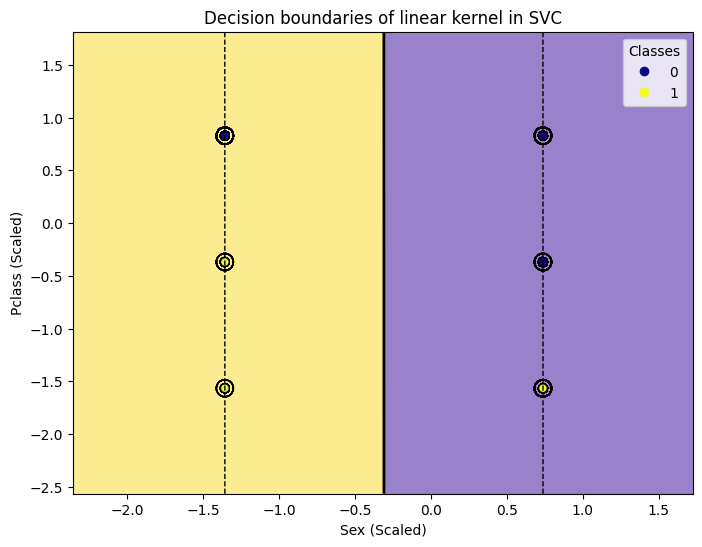

In [80]:
import matplotlib.pyplot as plt

# Plot ဆွဲခြင်း
plt.figure(figsize=(8, 6))

# နောက်ခံကို အရောင်ခြယ်ခြင်း (Decision Regions)
plt.contourf(xx, yy, Z, cmap='plasma', alpha=0.5)

# အလယ်မျဉ်း (Boundary) နဲ့  Margins မျဉ်းတွေကို ဆွဲခြင်း
P = model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.contour(xx, yy, P, colors='black', levels=[-1, 0, 1], alpha=1.0,
            linestyles=['--', '-', '--'], linewidths=[1, 2, 1])

# လူနာတွေရဲ့ ဒေတာအစက်လေးတွေကို ချခြင်း
scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_vis, s=40, 
                      cmap='plasma', edgecolors='k', label='Data Points')

# မျဉ်းကြောင်းကို အဓိက ထိန်းချုပ်နေတဲ့ Support Vectors အစက်တွေကို အဝိုင်းဝိုင်းပြခြင်း
plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=150,
            linewidth=1, facecolors='none', edgecolors='black', label='Support Vectors')

# ဝင်ရိုးအမည်များနှင့် ခေါင်းစဉ်များ တပ်ခြင်း
plt.xlabel('Sex (Scaled)')
plt.ylabel('Pclass (Scaled)')
plt.title('Decision boundaries of linear kernel in SVC')
plt.legend(*scatter.legend_elements(), title="Classes", loc="upper right")
plt.show()

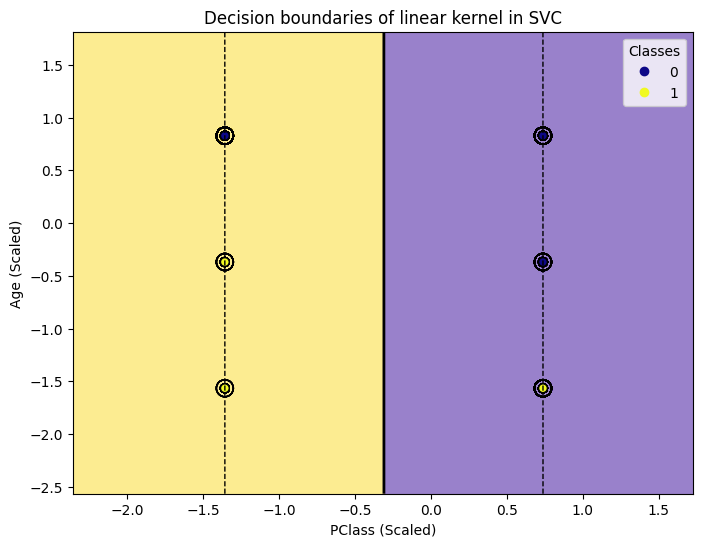

In [81]:
import matplotlib.pyplot as plt

# Plot ဆွဲခြင်း
plt.figure(figsize=(8, 6))

# နောက်ခံကို အရောင်ခြယ်ခြင်း (Decision Regions)
plt.contourf(xx, yy, Z, cmap='plasma', alpha=0.5)

# အလယ်မျဉ်း (Boundary) နဲ့  Margins မျဉ်းတွေကို ဆွဲခြင်း
P = model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
plt.contour(xx, yy, P, colors='black', levels=[-1, 0, 1], alpha=1.0,
            linestyles=['--', '-', '--'], linewidths=[1, 2, 1])

# လူနာတွေရဲ့ ဒေတာအစက်လေးတွေကို ချခြင်း
scatter = plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=y_vis, s=40, 
                      cmap='plasma', edgecolors='k', label='Data Points')

# မျဉ်းကြောင်းကို အဓိက ထိန်းချုပ်နေတဲ့ Support Vectors အစက်တွေကို အဝိုင်းဝိုင်းပြခြင်း
plt.scatter(model.support_vectors_[:, 0], model.support_vectors_[:, 1], s=150,
            linewidth=1, facecolors='none', edgecolors='black', label='Support Vectors')

# ဝင်ရိုးအမည်များနှင့် ခေါင်းစဉ်များ တပ်ခြင်း
plt.xlabel('PClass (Scaled)')
plt.ylabel('Age (Scaled)')
plt.title('Decision boundaries of linear kernel in SVC')
plt.legend(*scatter.legend_elements(), title="Classes", loc="upper right")
plt.show()